# Data Science PROJECT
### Census
    
    


###### The Task. 
The town from the census is a modestly sized one sandwiched between two much larger cities that it
is connected to by motorways. The town does not have a university, but students do live in the town and
commute to the nearby cities. Once you have a cleaned dataset to analyse, your task is to decide the following:

###### (a) What should be built on an unoccupied plot of land that the local government wishes to
develop? Your choices are:

- (i) High-density housing. This should be built if the population is significantly expanding.
- (ii) Low-density housing. This should be built if the population is “affluent” and there is
        demand for large family housing.
- (iii) Train station. There are potentially a lot of commuters in the town and building a train
        station could take pressure off the roads. But how will you identify commuters?
- (iv) Religious building. There is already one place of worship for Catholics in the town. Is
        there demand for a second Church (if so, which denomination?), or for a different religious building?
- (v) Emergency medical building. Not a full hospital, but a minor injuries centre. This should
        be built if there are many injuries or future pregnancies likely in the population.
- (vi) Something else?
- Whichever you choose, you must justify it from the data provided to you and argue it is a priority
    against other choices.

###### (b) Which one of the following options should be invested in?
- (i) Employment and training. If there is evidence for a lot of unemployment, we should retrain
people for new skills.
- (ii) Old age care. If there is evidence for increasing numbers of retired people in future years,
the town will need to allocate more funding for end of life care.
- (iii) Increase spending for schooling. If there is evidence of a growing population of schoolaged
children (new births, or families moving in to the town), then schooling spend should increase.
- (iv) General infrastructure. If the town is expanding, then services (waste collection; road
maintenance, etc.) will require more investment.

###### In order to address these two questions, it is suggested that some of the analysis you undertake is:
- Examine the age distribution (age pyramid) of the population. Is it growing or shrinking? Will
there be more retired aged people in the future, more school-aged children, more young
people, etc.
-  Examine unemployment trends. Are certain ages more likely to be unemployed than others.
-  Examine religious affiliations. Are any religions growing, or shrinking? Are there any newer
religions that are increasing in numbers?
-  Examine the divorce and marriage rate. This might impact how you think about housing.
-  Examine the occupancy level (how many people per house) and determine if existing housing
is being under or over-used.
-  Examine the number of university students. All of these are commuters since there are no
universities in the town. Are there any other professions that are likely to be commuters?
-  What is the birth rate and death rate for the town?
These are merely suggestions, there are plentiful other analyses that could be undertaken that will be
discussed in the videos and in class. Ultimately, your answers to (a) and (b) must be justified from the
census data, and argued by balancing the different needs of the population and supported through
statistics and where appropriate, hypothesis testing. As such, this is a “real” exercise but based on
artificial data. [As a disclaimer: any reference to real people or places, living

In [1]:
# Importing the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Allowing Pandas to display all the rows, by setting the maximum naximum number of rows to None 
pd.set_option("display.max_rows", None)

In [4]:
# Read in the census11 csv file into a pandas dataframe. 

file_path = r'\\adir.hull.ac.uk\home\753\753220\Desktop\80% Assignment 28.4.2023\census11.csv'
df = pd.read_csv(file_path)

###### STEP 1: PRINTING SUMMATIVE INFORMATION ABOUT THE DATASET 

In [5]:
# Inspecting the general layout of the dataset
df.head(3)

,House Number,Street,First Name,Surname,Age,Relationship to Head of House,Marital Status,Gender,Occupation,Infirmity,Religion
0,1,Regentchain Avenue,Ashleigh,Dale,41,Head,Divorced,Female,Field trials officer,NaN,Catholic
1,1,Regentchain Avenue,Deborah,Dale,11,Daughter,NaN,Female,Student,NaN,NaN
2,1,Regentchain Avenue,Gary,Dale,7,Son,NaN,Male,Student,NaN,NaN


In [6]:
# Get the dataframe information.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8377 entries, 0 to 8376
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   House Number                   8377 non-null   int64 
 1   Street                         8377 non-null   object
 2   First Name                     8377 non-null   object
 3   Surname                        8377 non-null   object
 4   Age                            8377 non-null   object
 5   Relationship to Head of House  7778 non-null   object
 6   Marital Status                 6402 non-null   object
 7   Gender                         8377 non-null   object
 8   Occupation                     8377 non-null   object
 9   Infirmity                      69 non-null     object
 10  Religion                       3525 non-null   object
dtypes: int64(1), object(10)
memory usage: 720.0+ KB


##### STEP 2: CLEANING THE DATA

###### CLEANING THE DATASET INVOLVES;
1. FIXING STRUCTURAL ERRORS AND INCONSISTENCIES
2. HANDLING MISSING DATA 

This will be done column by column to make sure each single cell is checked for structural errors and missing data, 
Structural errors will be fixed on case by case basis, then missing values will be corrected by inputing values based on actual observations from the data.

In [7]:
# Check for duplicates 
df.duplicated().sum()

0

In [8]:
# Check for null (NaN) values 
df.isna().sum()

House Number                        0
Street                              0
First Name                          0
Surname                             0
Age                                 0
Relationship to Head of House     599
Marital Status                   1975
Gender                              0
Occupation                          0
Infirmity                        8308
Religion                         4852
dtype: int64

There are two columns with NaN values; 'Marital Status'  ==> 1975 and 'Religion' ==> 2012.

###### COLUMN 1: HOUSE NUMBER  

In [9]:
# Checking for missing values in column No. 1: 'House Number'
df[df['House Number'] == ' ']

,House Number,Street,First Name,Surname,Age,Relationship to Head of House,Marital Status,Gender,Occupation,Infirmity,Religion


There are no missing values under the 'House Number' column 

###### COLUMN 2: STREET  

In [10]:
#Checking for missing values in column No. 2: 'Street'
df[df['Street'] == ' ']

,House Number,Street,First Name,Surname,Age,Relationship to Head of House,Marital Status,Gender,Occupation,Infirmity,Religion


There are no missing values under the 'Street' column

###### COLUMN NO. 3: FIRST NAME 

In [11]:
# Checking for missing values under the 'First Name' column
df[df['First Name'] == ' ']

,House Number,Street,First Name,Surname,Age,Relationship to Head of House,Marital Status,Gender,Occupation,Infirmity,Religion
1497,4,Power Keys,,Frost,88,Head,Widowed,Male,Retired Civil Service fast streamer,NaN,Methodist


In [12]:
#Looking for appropriate first name for Mr Frost 
df[1496:1499]

,House Number,Street,First Name,Surname,Age,Relationship to Head of House,Marital Status,Gender,Occupation,Infirmity,Religion
1496,3,Power Keys,Kelly,Chapman,80,Head,Single,Female,Retired Web designer,NaN,Christian
1497,4,Power Keys,,Frost,88,Head,Widowed,Male,Retired Civil Service fast streamer,NaN,Methodist
1498,5,Power Keys,Beth,Singh,45,Head,Married,Female,Unemployed,NaN,NaN


In [13]:
# Replacing missing first name with Mr. instead of making up a name for him. He can still be identified, easily with Mr Frost.
df['First Name'] = df['First Name'].replace(' ', 'Mr')

# Checking for result 
df[1497:1498]

,House Number,Street,First Name,Surname,Age,Relationship to Head of House,Marital Status,Gender,Occupation,Infirmity,Religion
1497,4,Power Keys,Mr,Frost,88,Head,Widowed,Male,Retired Civil Service fast streamer,NaN,Methodist


###### SURNAME

In [14]:
# Looking for missing values in 'Surname'
df[df['Surname'] == ' ']

,House Number,Street,First Name,Surname,Age,Relationship to Head of House,Marital Status,Gender,Occupation,Infirmity,Religion
60,8,Telegraphnet Street,Linda,,41,Daughter,Single,Female,Commercial art gallery manager,NaN,Christian
4236,48,Chan Estate,Denise,,9,Adopted Daughter,NaN,Female,Student,NaN,NaN


In [15]:
# Detecting the appropriate surname for Linda 
df[57:62]

,House Number,Street,First Name,Surname,Age,Relationship to Head of House,Marital Status,Gender,Occupation,Infirmity,Religion
57,8,Telegraphnet Street,Elaine,Patel,78,Head,Divorced,Female,Retired Clinical biochemist,NaN,Christian
58,8,Telegraphnet Street,Kate,Patel,44,Daughter,Single,Female,Translator,NaN,Christian
59,8,Telegraphnet Street,Damien,Patel,42,Son,Single,Male,Tourist information centre manager,NaN,Christian
60,8,Telegraphnet Street,Linda,,41,Daughter,Single,Female,Commercial art gallery manager,NaN,Christian
61,8,Telegraphnet Street,Patricia,Patel,38,Daughter,Divorced,Female,Psychiatrist,NaN,Christian


In [16]:
# Linda is a daughter in her household, so I assumed she has same Surname with the rest of the household 
df.at[60, "Surname"] = 'Patel'
df[60:61]

,House Number,Street,First Name,Surname,Age,Relationship to Head of House,Marital Status,Gender,Occupation,Infirmity,Religion
60,8,Telegraphnet Street,Linda,Patel,41,Daughter,Single,Female,Commercial art gallery manager,NaN,Christian


In [17]:
# Checking for appropriate surname for Denise
df[4232:4237]

,House Number,Street,First Name,Surname,Age,Relationship to Head of House,Marital Status,Gender,Occupation,Infirmity,Religion
4232,48,Chan Estate,Francesca,Lloyd,37,Head,Married,Female,Drilling engineer,NaN,Catholic
4233,48,Chan Estate,Shane,Lloyd,41,Husband,Married,Male,Banker,NaN,Catholic
4234,48,Chan Estate,Alexandra,Lloyd,13,Daughter,NaN,Female,Student,NaN,NaN
4235,48,Chan Estate,Arthur,Lloyd,12,Son,NaN,Male,Student,NaN,NaN
4236,48,Chan Estate,Denise,,9,Adopted Daughter,NaN,Female,Student,NaN,NaN


In [18]:
# Denise is a 9 yr-old member of the Lloyd's household at 48 Chan Estate. 
# Though she is adopted, I assigned the Lloyds surname to her, for easy identification, at least
df.at[4236, "Surname"] = 'Lloyd'

# Checking for result 
df[4236:4237]

,House Number,Street,First Name,Surname,Age,Relationship to Head of House,Marital Status,Gender,Occupation,Infirmity,Religion
4236,48,Chan Estate,Denise,Lloyd,9,Adopted Daughter,NaN,Female,Student,NaN,NaN


###### AGE

In [19]:
# Checking for missing values under 'Age'
df[df['Age'] == ' ']

,House Number,Street,First Name,Surname,Age,Relationship to Head of House,Marital Status,Gender,Occupation,Infirmity,Religion
4000,6,Pendragon Lane,Howard,Baker,,Son,Single,Male,University Student,NaN,Methodist


In [20]:
# Guessing the age 
df[3999:4004]

,House Number,Street,First Name,Surname,Age,Relationship to Head of House,Marital Status,Gender,Occupation,Infirmity,Religion
3999,6,Pendragon Lane,Zoe,Baker,43,Head,Single,Female,Field trials officer,NaN,Methodist
4000,6,Pendragon Lane,Howard,Baker,,Son,Single,Male,University Student,NaN,Methodist
4001,6,Pendragon Lane,Vanessa,Baker,19,Daughter,Single,Female,University Student,NaN,Methodist
4002,6,Pendragon Lane,Leslie,Baker,19,Son,Single,Male,University Student,NaN,Methodist
4003,7,Pendragon Lane,Holly,Singh,28,Head,Married,Female,"Designer, graphic",NaN,NaN


In [21]:
# I replaced missing value with 21. Since he is still a university student 
# Moreover, the baker home already has a set of twin and the probability of him being a part of a triplet is very low. 
# According to the Cosmoplitan Magazine; Just 132 women gave birth to triplets or above in 2018, which equates to a 0.02% chance of birthing three or more kids at once.

df['Age'] = df['Age'].replace(' ', 21)

# To confirm
df[4000:4001]

,House Number,Street,First Name,Surname,Age,Relationship to Head of House,Marital Status,Gender,Occupation,Infirmity,Religion
4000,6,Pendragon Lane,Howard,Baker,21,Son,Single,Male,University Student,NaN,Methodist


In [22]:
# # To confirm zero null values
df['Age'].isna().sum()

0

In [23]:
# Converting age to integer for easier analysis
df['Age'] = df['Age'].astype(float)
df['Age'] = df['Age'].astype(int)

# To confirm
df['Age'].dtype

dtype('int32')

###### MARITAL STATUS

In [24]:
# Checking unique values under 'Marital status'
df['Marital Status'].value_counts()

Marital Status
Single      2999
Married     2224
Divorced     791
Widowed      387
               1
Name: count, dtype: int64

In [25]:
#Checking for Null values.
df['Marital Status'].isna().sum()

1975

In [26]:
df[df['Marital Status'] == ' ']

,House Number,Street,First Name,Surname,Age,Relationship to Head of House,Marital Status,Gender,Occupation,Infirmity,Religion
4230,47,Chan Estate,Norman,Ward,25,Son,,Male,Administrator,NaN,NaN


In [27]:
#Detecting approriate status for missing marital status
df[4228:4232]

,House Number,Street,First Name,Surname,Age,Relationship to Head of House,Marital Status,Gender,Occupation,Infirmity,Religion
4228,47,Chan Estate,Jemma,Ward,41,Head,Married,Female,Unemployed,NaN,Christian
4229,47,Chan Estate,Maurice,Ward,44,Husband,Married,Male,Unemployed,NaN,Christian
4230,47,Chan Estate,Norman,Ward,25,Son,,Male,Administrator,NaN,NaN
4231,47,Chan Estate,Ronald,Ward,12,Son,NaN,Male,Student,NaN,NaN


In [28]:
#Replacing and checking for result 
# I Assumed Norman is single as he is still living his parents 
df['Marital Status']=df['Marital Status'].replace (' ','Single')
df[4230:4231]

,House Number,Street,First Name,Surname,Age,Relationship to Head of House,Marital Status,Gender,Occupation,Infirmity,Religion
4230,47,Chan Estate,Norman,Ward,25,Son,Single,Male,Administrator,NaN,NaN


In [29]:
# Check for NaN values
df['Marital Status'].isna().sum()

1975

In [30]:
# How many of the NaN values are under 18?
((df['Marital Status']).isna() & (df['Age']<18)).sum()

# It turns out that all are under 18

1975

In [31]:
# Since the legal age for marriage in the UK is now 18, I filled it with 'Minor'
df['Marital Status'] = df['Marital Status'].fillna('Minor/NA') # Please note that NA means 'Not Applicable' 

In [32]:
# Checking 'Marital Status' after cleaning.
df['Marital Status'].value_counts()

Marital Status
Single      3000
Married     2224
Minor/NA    1975
Divorced     791
Widowed      387
Name: count, dtype: int64

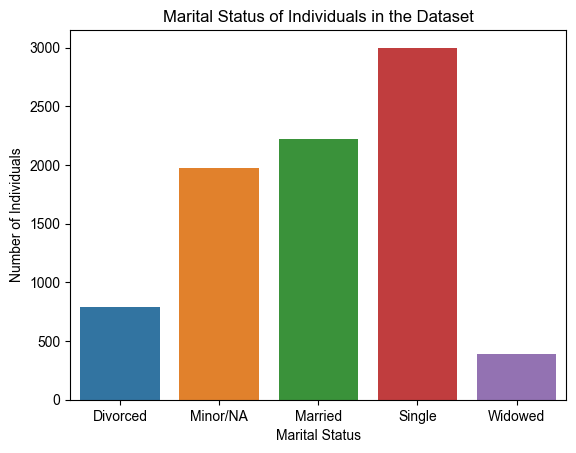

In [33]:
# Plotting a simple chart to illustrate the Marital Status 
# plot bar graph
sns.countplot(x='Marital Status', data=df)
sns.set_style('whitegrid')
plt.xlabel('Marital Status')
plt.ylabel('Number of Individuals')
plt.title('Marital Status of Individuals in the Dataset');

###### Age Distribution of the Marital Status

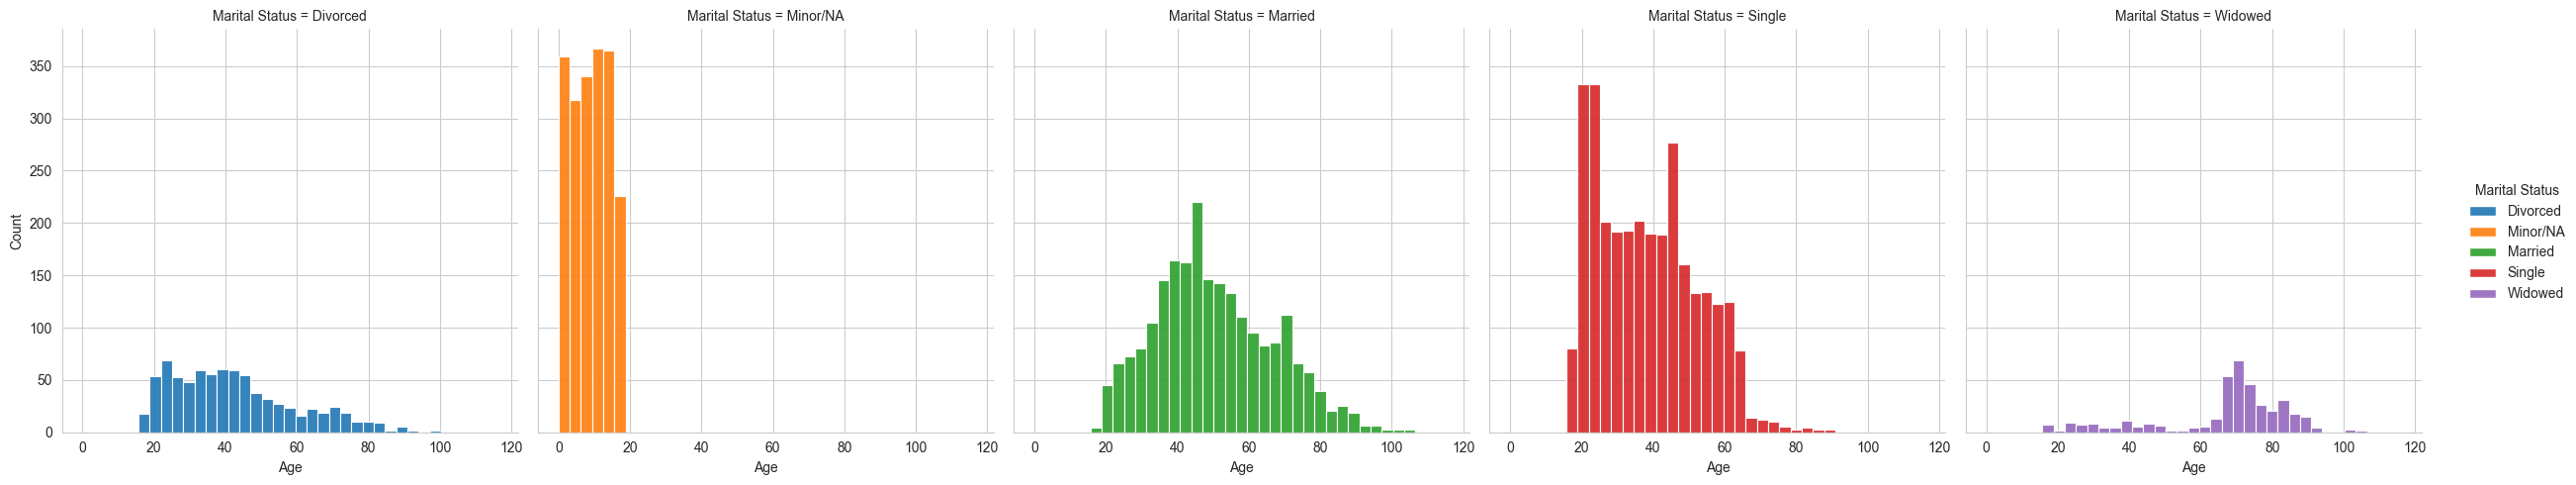

In [34]:
# Plotting the age distribution of Marital Status
sns.displot(x = 'Age', data = df, kind = 'hist', hue = 'Marital Status', col = 'Marital Status',alpha = 0.9);

###### GENDER

In [35]:
# Checking for missing values under 'Gender'
df[df['Gender'] == ' ']

,House Number,Street,First Name,Surname,Age,Relationship to Head of House,Marital Status,Gender,Occupation,Infirmity,Religion
1002,1,Taylor Grove,Pamela,Edwards,69,Head,Married,,"Retired Engineer, technical sales",NaN,Christian
6899,8,Tiger Avenue,Leanne,Gill,22,NaN,Single,,University Student,NaN,NaN
7348,25,Canterbury Well,Irene,Harvey,51,Head,Married,,"Librarian, public",NaN,Christian


In [36]:
# Checking for appropriate Gender for Pamela Edwards 
df[1002:1005]
# Pamela Edwards, 69 is the Head of House at 1 Taylor Grove. The only other resident in that house is a married male.
# Since the there are only two genders in the Census. It is reasonable to assume that Pamela the wife and therefore female.

,House Number,Street,First Name,Surname,Age,Relationship to Head of House,Marital Status,Gender,Occupation,Infirmity,Religion
1002,1,Taylor Grove,Pamela,Edwards,69,Head,Married,,"Retired Engineer, technical sales",NaN,Christian
1003,1,Taylor Grove,Garry,Edwards,72,Husband,Married,Male,Retired Ophthalmologist,NaN,Christian
1004,2,Taylor Grove,Olivia,Rose,73,Head,Widowed,Female,Retired Ergonomist,NaN,NaN


In [37]:
# Checking for appropriate gender for Irene Harvey, based on her relationship with the rest of her house

df[7347:7352]

,House Number,Street,First Name,Surname,Age,Relationship to Head of House,Marital Status,Gender,Occupation,Infirmity,Religion
7347,24,Canterbury Well,Dominic,Alexander,62,Head,Single,Male,Electronics engineer,NaN,NaN
7348,25,Canterbury Well,Irene,Harvey,51,Head,Married,,"Librarian, public",NaN,Christian
7349,25,Canterbury Well,Christopher,Harvey,55,Husband,Married,Male,Curator,NaN,Christian
7350,25,Canterbury Well,Carolyn,Harvey,28,Daughter,Single,Female,Land/geomatics surveyor,NaN,Christian
7351,25,Canterbury Well,Holly,Harvey,12,Daughter,Minor/NA,Female,Student,NaN,NaN


In [38]:
# Checking for appropriate Gender for Leane Gill 
df[6898:6900]
# As seen below, Leanne Gill has no relationship with Head of House of 8 Tiger Avenue, Both are the only occupants.
# Therefore Leanne Gill gender will be repleced with Female since she has a typical female name.

,House Number,Street,First Name,Surname,Age,Relationship to Head of House,Marital Status,Gender,Occupation,Infirmity,Religion
6898,8,Tiger Avenue,Gillian,Smith,43,Head,Single,Female,Database administrator,NaN,Christian
6899,8,Tiger Avenue,Leanne,Gill,22,NaN,Single,,University Student,NaN,NaN


In [39]:
# Replacing the missing Gender was based on 2 conditions
# 1. Replacement by relation to other family members. Pamela with index no.(1002) has a husband; Gary. Same applies to Irene Harvey. 51, at index 7348, who is the head of her house at 25 Canterbury Well

# 2. The partcipants have typical female names missing values with 'Female', since the responders have typical female names. Remember that other responses were not implemented in 1881
df['Gender']=df['Gender'].replace(' ','Female')

# Checking the unique values to confirm we have only male and female genders on the dataset.
df['Gender'].unique().tolist()

['Female', 'Male']

###### OCCUPATION

In [40]:
# Checking for missing values under the occupation column
df[df['Occupation'] == ' ']

,House Number,Street,First Name,Surname,Age,Relationship to Head of House,Marital Status,Gender,Occupation,Infirmity,Religion
3399,194,Harvey Road,Josephine,Anderson,73,Head,Divorced,Female,,NaN,Christian


In [41]:
# Detecting for appropriate occupation 
df[3398:3401]

,House Number,Street,First Name,Surname,Age,Relationship to Head of House,Marital Status,Gender,Occupation,Infirmity,Religion
3398,193,Harvey Road,Damian,Wheeler,74,Head,Widowed,Male,Retired Diplomatic Services operational officer,NaN,Methodist
3399,194,Harvey Road,Josephine,Anderson,73,Head,Divorced,Female,,NaN,Christian
3400,195,Harvey Road,Jeremy,Hodgson,49,Head,Divorced,Male,Investment analyst,NaN,NaN


In [42]:
# There is no way correct way to determine the occupation, so i settled for 'Unknown' instead of dropping the row 

df.at[3399, 'Occupation'] = 'Retired' # Although default retirement age' (a forced retirement age of 65) no longer exists in the UK. It is safe to assume that Josephine Anderson is likely to be retired at the age of 73

# Making the change pemananent by re-assigning the variable
df['Occupation'] = df['Occupation']

# Confirming input 
df[3399:3400]

,House Number,Street,First Name,Surname,Age,Relationship to Head of House,Marital Status,Gender,Occupation,Infirmity,Religion
3399,194,Harvey Road,Josephine,Anderson,73,Head,Divorced,Female,Retired,NaN,Christian


In [88]:
# Extracting the total number of retirees in the dataset.
rows_with_retired = df[df['Occupation'].str.contains('retired', case=False)]
print(len(rows_with_retired))

750


###### INFIRMITY 

In [45]:
# Checking for missing values in the 'Infirmity' column
df['Infirmity'].value_counts()

Infirmity
Physical Disability    18
                       13
Mental Disability      10
Blind                   9
Disabled                8
Deaf                    7
Unknown Infection       4
Name: count, dtype: int64

In [46]:
#Replacing missing values with 'Prefer not to say' seems to be the most appropriate
df['Infirmity'] = df['Infirmity'].replace(' ', 'Prefer not to say')

In [47]:
#Checking 
df['Infirmity'].value_counts()
#The 13 missing values have been replaced with 'Prefer not to say'

Infirmity
Physical Disability    18
Prefer not to say      13
Mental Disability      10
Blind                   9
Disabled                8
Deaf                    7
Unknown Infection       4
Name: count, dtype: int64

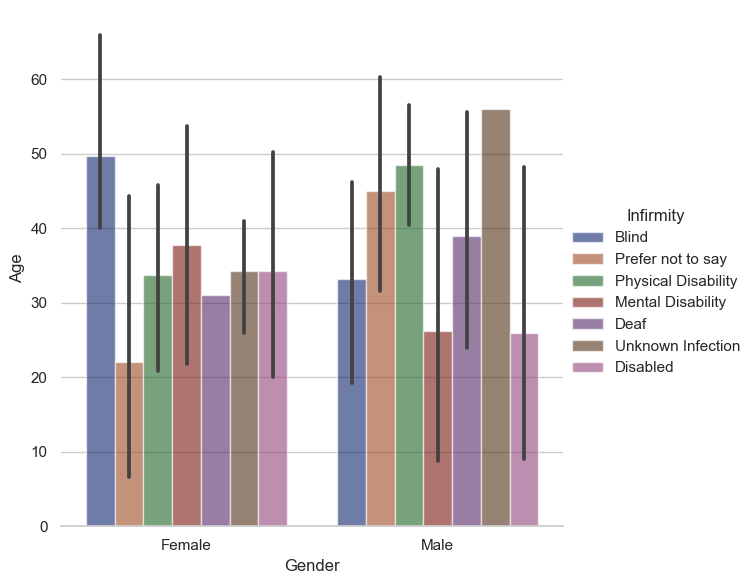

In [48]:
# Infirmity as it affects the Genders and Ages 
sns.set_theme(style="whitegrid")


# Draw a nested barplot by age and infirmity 
g = sns.catplot(data=df, kind="bar", x="Gender", y="Age", hue="Infirmity", palette="dark", alpha=.6, height=6)
g.despine(left=True);

###### RELIGION

In [49]:
# To get the unique entries in a the 'Religion', column
# Notice that in the census questionnaire participants filled things like 'Jedi', 'Housekeeper' as religions. Many left it blank. 
# Some indicated 'Private', meaning that they prefer not share this information.
# I will reduce the number of unique values in this column 
# by replacing 'Jedi','Quaker','Housekeeper', some blanks, and even 'Private' with 'Prefer not to say' which is what I assume participants would want to state.  

df['Religion'].unique()

array(['Catholic', nan, 'Methodist', 'Christian', 'Jewish', 'Sikh',
       'Muslim', 'Buddist', 'Quaker', 'Housekeeper', 'Jedi', 'Pagan', ' ',
       'Private', 'Orthodoxy'], dtype=object)

In [50]:
# I will start with empty values; " " 
df[df['Religion'] == ' ']

,House Number,Street,First Name,Surname,Age,Relationship to Head of House,Marital Status,Gender,Occupation,Infirmity,Religion
4288,12,Jones Ramp,Jane,Armstrong,46,Wife,Married,Female,Garment/textile technologist,NaN,
7487,58,Canterbury Well,Christopher,Cole,15,Son,Minor/NA,Male,Student,NaN,


In [51]:
# It will make sense to replace Jane Armstrong's empty values in Religion with 'Prefer not to say', since the participant left it blank

df.at[4288, "Religion"] = 'Prefer not to say'
#To confirm
df.iloc[[4288]]

,House Number,Street,First Name,Surname,Age,Relationship to Head of House,Marital Status,Gender,Occupation,Infirmity,Religion
4288,12,Jones Ramp,Jane,Armstrong,46,Wife,Married,Female,Garment/textile technologist,NaN,Prefer not to say


In [52]:
# Since Christopher Cole is still a minor, the youngest in the househeld, I assumed that his Religion will be same with his parents.
# However, as shown below some of his older siblings clearly indicated that they do not have religious affiliations.

# Note that Article 14 of the UNCRC says that children and young people are free to be of any or no religion. Their parents can help them make decisions around religion, but: a parent can't force a child or young person to adopt a religion,


df[7482:7489]

,House Number,Street,First Name,Surname,Age,Relationship to Head of House,Marital Status,Gender,Occupation,Infirmity,Religion
7482,58,Canterbury Well,Daniel,Cole,62,Head,Single,Male,Water quality scientist,NaN,Methodist
7483,58,Canterbury Well,Linda,Wallace,59,Partner,Single,Female,"Buyer, retail",NaN,Methodist
7484,58,Canterbury Well,Donna,Cole,25,Daughter,Single,Female,Maintenance engineer,NaN,NaN
7485,58,Canterbury Well,Deborah,Cole,21,Daughter,Single,Female,University Student,NaN,Methodist
7486,58,Canterbury Well,Gerard,Cole,19,Son,Single,Male,University Student,NaN,NaN
7487,58,Canterbury Well,Christopher,Cole,15,Son,Minor/NA,Male,Student,NaN,
7488,1,Daffodilhatch Street,Denis,Wright,77,Head,Widowed,Male,Retired Film/video editor,NaN,NaN


In [53]:
# Changing Christopher Cole's Religion to Methodist 
df.at[7487, "Religion"] = 'Methodist'
# To confirm
df.iloc[[7487]]

,House Number,Street,First Name,Surname,Age,Relationship to Head of House,Marital Status,Gender,Occupation,Infirmity,Religion
7487,58,Canterbury Well,Christopher,Cole,15,Son,Minor/NA,Male,Student,NaN,Methodist


In [54]:
# To reduce the number of unique values under the Religion column
df['Religion'] = df['Religion'].replace('Quaker', 'Christian') # Quakers are a subset of Protestant Christian denomination
df['Religion'] = df['Religion'].replace ('Housekeeper', 'Prefer not to say') # Housekeeper is  not a recognized religion
df['Religion'] = df['Religion'].replace ('Jedi', 'Prefer not to say') # Jedi is not a recognized religion
df['Religion'] = df['Religion'].replace ('Private', 'Prefer not to say') # 'Private' was merged with 'Prefer not to say' to reduce the number of unique values under the religious column

Treating the NaN values

In [55]:
# Total number of NaN entries in the Religion column
df['Religion'].isna().sum()

4852

In [56]:
# Out of the 2012 entries with NaN in the religion column, 1978 are children.(Under 18)
(df['Religion'].isna() & (df['Age']<18)).sum()

1978

In [57]:
#34 of them are >= 18 
(df['Religion'].isna() & (df['Age']>=18)).sum()

2874

In [58]:
# Filling the Religion of the >=18 with 'Prefer not to say', assuming that the participant deliberately did not want to fill that part of census questionnaire

df.loc[(df['Religion'].isnull()) & (df['Age'] >= 18), 'Religion'] = 'Prefer not to say'

#Making the change permanent 
df=df

In [59]:
#Checking 
(df['Religion'].isna() & (df['Age']>=18)).sum()

0

In [60]:
#Remaining only the <18
df['Religion'].isna().sum()

1978

In [61]:
# Replace Minor's with NaN as their religion with head of household's religion
minors = df[(df['Age'] < 18) & (df['Religion'].isna())]
for i in minors.index:
    df.at[i, 'Religion'] = df.loc[(df['House Number'] == df.at[i, 'House Number']) & (df['Relationship to Head of House'] == 'Head'), 'Religion'].iloc[0]

In [62]:
#To confirm

df[(df['Age'] < 18) & (df['Religion'])]

,House Number,Street,First Name,Surname,Age,Relationship to Head of House,Marital Status,Gender,Occupation,Infirmity,Religion
1,1,Regentchain Avenue,Deborah,Dale,11,Daughter,Minor/NA,Female,Student,NaN,Catholic
2,1,Regentchain Avenue,Gary,Dale,7,Son,Minor/NA,Male,Student,NaN,Catholic
6,2,Regentchain Avenue,Mandy,Grant,17,Daughter,Minor/NA,Female,Student,NaN,Methodist
7,2,Regentchain Avenue,Amanda,Grant,11,Daughter,Minor/NA,Female,Student,NaN,Methodist
14,4,Regentchain Avenue,Sandra,Price,4,Daughter,Minor/NA,Female,Child,NaN,Prefer not to say
27,7,Regentchain Avenue,Leon,Webster,12,Son,Minor/NA,Male,Student,NaN,Methodist
28,7,Regentchain Avenue,Gregory,Stone,9,Son,Minor/NA,Male,Student,NaN,Methodist
41,4,Telegraphnet Street,Lisa,Williams,15,Daughter,Minor/NA,Female,Student,NaN,Prefer not to say
42,4,Telegraphnet Street,Linda,Williams,10,Daughter,Minor/NA,Female,Student,NaN,Prefer not to say
44,5,Telegraphnet Street,Simon,Taylor,16,Son,Minor/NA,Male,Student,NaN,Prefer not to say


In [63]:
# To confirm
df['Religion'].isna().sum()

0

In [64]:
# listing the Religions S
df['Religion'].value_counts()

Religion
Prefer not to say    3584
Christian            2597
Catholic             1209
Methodist             785
Muslim                119
Sikh                   42
Jewish                 36
Buddist                 3
Pagan                   1
Orthodoxy               1
Name: count, dtype: int64

###### A chart showing the Age Distribution of the Various Religion

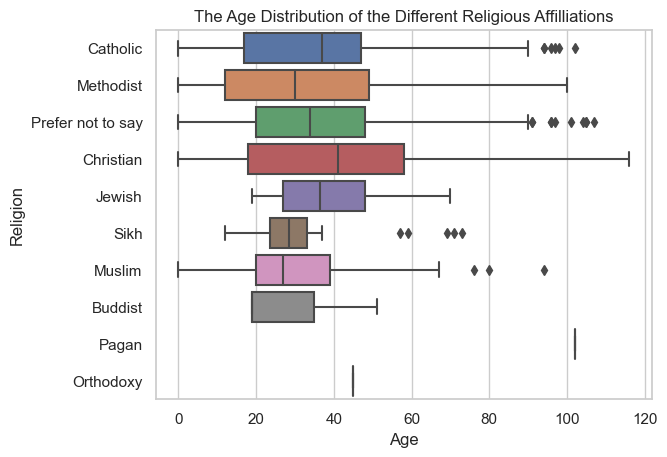

In [65]:
# Create a countplot of the different religions
sns.boxplot(x = 'Age',y = 'Religion', data=df);
plt.title('The Age Distribution of the Different Religious Affilliations');

###### Data Information after Cleaning

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8377 entries, 0 to 8376
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   House Number                   8377 non-null   int64 
 1   Street                         8377 non-null   object
 2   First Name                     8377 non-null   object
 3   Surname                        8377 non-null   object
 4   Age                            8377 non-null   int32 
 5   Relationship to Head of House  7778 non-null   object
 6   Marital Status                 8377 non-null   object
 7   Gender                         8377 non-null   object
 8   Occupation                     8377 non-null   object
 9   Infirmity                      69 non-null     object
 10  Religion                       8377 non-null   object
dtypes: int32(1), int64(1), object(9)
memory usage: 687.3+ KB


### STEP 3: VISUALIZATION AND ANALYSIS


###### PLOTTING THE AGE PYRAMID 

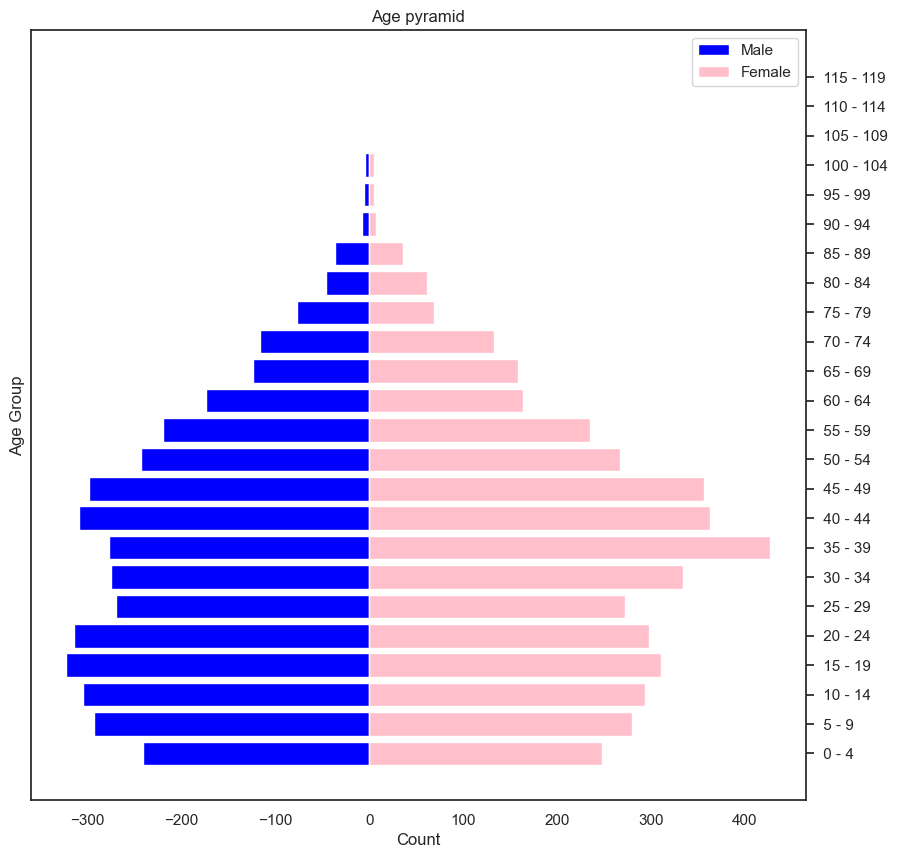

In [89]:
# Group the data by age and gender, and calculate the count for each groupmin_age
min_age = int(df['Age'].min())
max_age = int(df['Age'].max() + 0.1)

bin_size = 5
bins = range(min_age, max_age + bin_size, bin_size)



df['Age Group'] = pd.cut(df['Age'], bins = bins,  labels = [f' {i} - {i + bin_size-1}' for i in bins[: -1 ]]) 
grouped = df.groupby(['Age Group', 'Gender'])['First Name'].count().reset_index()

# Pivot the data to create the population pyramid
male_data = grouped[grouped['Gender'] == 'Male'].set_index('Age Group').sort_index(ascending=True)
female_data = grouped[grouped['Gender'] == 'Female'].set_index('Age Group').sort_index(ascending=True)

# Plot the population pyramid
fig, ax = plt.subplots(figsize=(10, 10))
# Plot male and female bars separately 
ax.barh(male_data.index.astype(str), -male_data['First Name'], align='center', color='blue')
ax.barh(female_data.index.astype(str), female_data['First Name'], align='center', color='pink')

# Add labels and formatting
ax.set_xlabel('Count')
ax.set_ylabel('Age Group')
ax.set_title('Age pyramid')
ax.yaxis.tick_right()
ax.legend(['Male', 'Female']);

###### CALCULATING THE AGE DISTRIBUTION

In [68]:
# CALCULATING THE AGE DISTRIBUTION 

ages = df['Age'].tolist()


# Counters for age groups
age_group_0_15 = 0
age_group_16_65 = 0
age_group_66_plus = 0

# Looping and incrementing the appropriate age group.
for age in ages:
    if age <= 15:
        age_group_0_15 += 1
    elif age <= 65:
        age_group_16_65 += 1
    else:
        age_group_66_plus += 1

# Print the results
print("THE AGE DISTRIBUTION OF THE TOWN:")
print("School Aged Children; (0-15 yrs old): ", age_group_0_15)# This is the age when most are supposed to be in school
print("Working Age Group (16-65 yrs old): ", age_group_16_65) # Legal age to work in the UK starts from 16 years old.
print("Elderly (66 yrs old and above): ", age_group_66_plus) # UK state pension starts from 66 yrs old 

THE AGE DISTRIBUTION OF THE TOWN:
School Aged Children; (0-15 yrs old):  1750
Working Age Group (16-65 yrs old):  5730
Elderly (66 yrs old and above):  897


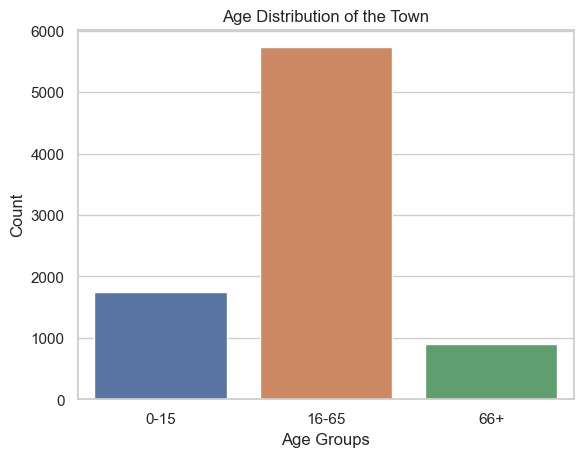

In [69]:
# Plotting a Chart for the Age distribution
age_groups = ['0-15', '16-65', '66+']
count = [1750, 5730, 897]
gender = df['Gender']

# Create a bar plot using Seaborn
sns.barplot(x=age_groups, y=count)

# Add labels and title
plt.xlabel('Age Groups')
plt.ylabel('Count')
plt.title('Age Distribution of the Town');


###### Age Distribution of the Marital Status

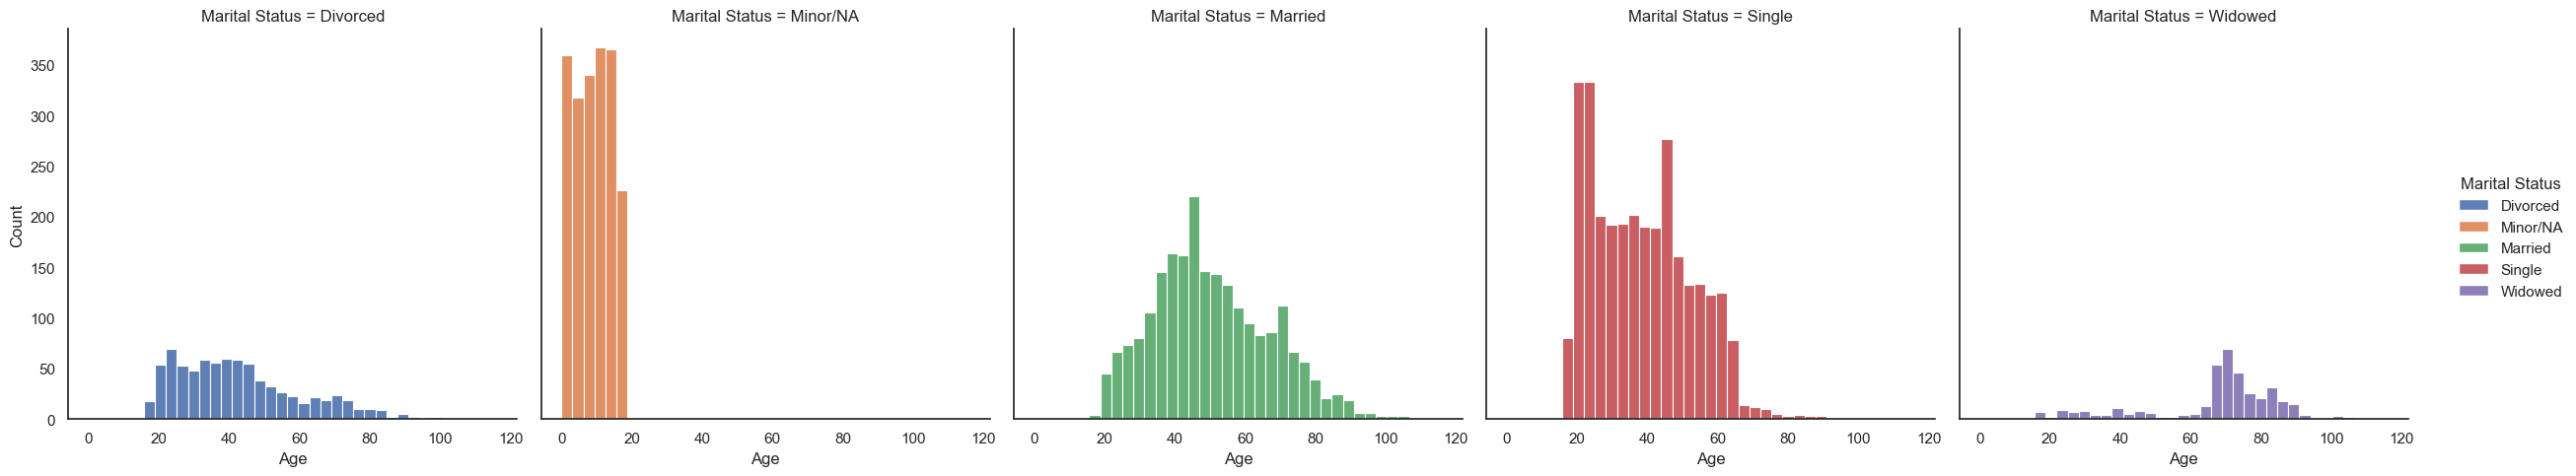

In [90]:
# Plotting the age distribution of Marital Status
sns.displot(x = 'Age', data = df, kind = 'hist', hue = 'Marital Status', col = 'Marital Status',alpha = 0.9);

###### Gender Distribution of the Marital Status

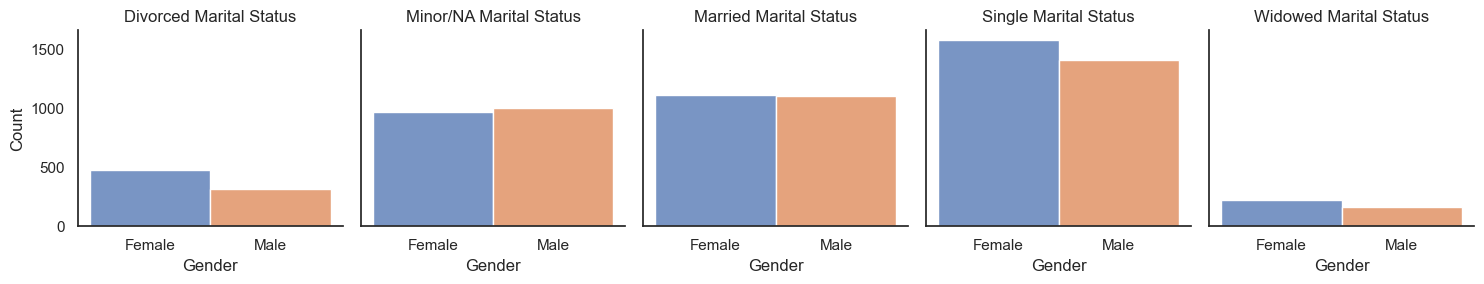

In [71]:
# Plotting the Gender Distribution of Marital Status
sns.set_style('white')
g=sns.FacetGrid(df, col ='Marital Status', hue = 'Gender');
g.map(sns.histplot,'Gender');
g.set_titles(col_template = '{col_name} Marital Status');

###### EXAMINING THE UNEMPLOYMENT TRENDS. 
Examine unemployment trends. Are certain ages more likely to be unemployed than others

In [72]:
# Calculating the total number of Unemployed 
Unemployed = 0
for occupation in df['Occupation']:
    if occupation == 'Unemployed':
        Unemployed += 1
print("Total number of unemployed:", + Unemployed)

Total number of unemployed: 529


In [73]:
# Calculating the total number of Students 
Students = 0
for occupation in df['Occupation']:
    if occupation == 'University Student' or occupation == 'PhD Student':
        Students += 1
print(Students)

543


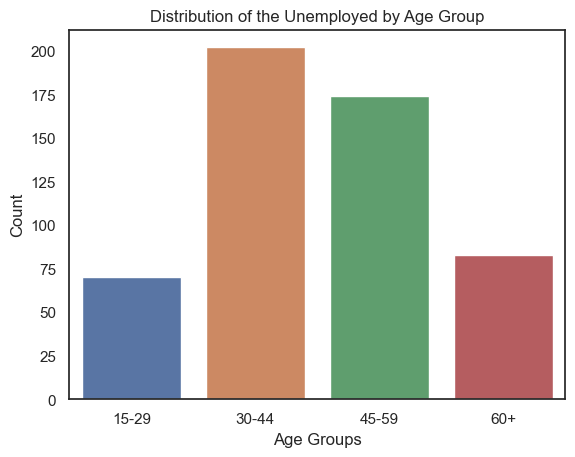

In [91]:
# Plotting a graph showing working age groups mostly affected by unemployment
# create a new dataframe with the counts of unemployed individuals in each age group
all_unemployed = pd.DataFrame({'Age Group': ['15-29', '30-44', '45-59', '60+'], 
                                  'Count': [df[(df['Occupation'] == 'Unemployed') & (df['Age'] >= 15) & (df['Age'] <= 29)]['Occupation'].count(),
                                            df[(df['Occupation'] == 'Unemployed') & (df['Age'] >= 30) & (df['Age'] <= 44)]['Occupation'].count(),
                                            df[(df['Occupation'] == 'Unemployed') & (df['Age'] >= 45) & (df['Age'] <= 59)]['Occupation'].count(),
                                            df[(df['Occupation'] == 'Unemployed') & (df['Age'] >= 60)]['Occupation'].count()]})

sns.barplot(x='Age Group', y='Count', data=all_unemployed);
plt.xlabel('Age Groups')
plt.title('Distribution of the Unemployed by Age Group');

###### USING VISUALIZATION TO SHOW THE MOST POPULATED STREET

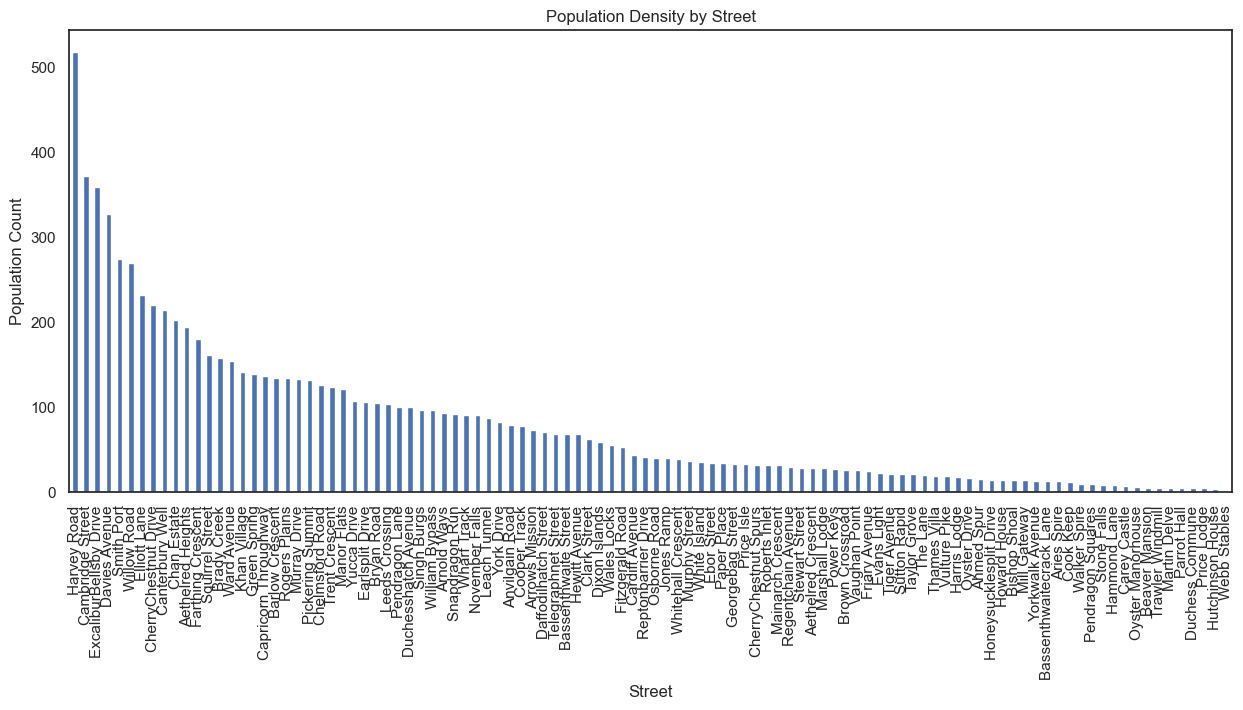

In [92]:
#THE POPULATION DENSITY BY STREET 

# group the data by street and count the number of residents
pop_count = df.groupby('Street')['First Name'].count()

# sort the streets by population count in descending order
pop_count = pop_count.sort_values(ascending=False)

# plot the bar chart
pop_count.plot(kind='bar', figsize=(15,6))
plt.title('Population Density by Street')
plt.xlabel('Street')
plt.ylabel('Population Count');

###### Age Distribution of Infirmities

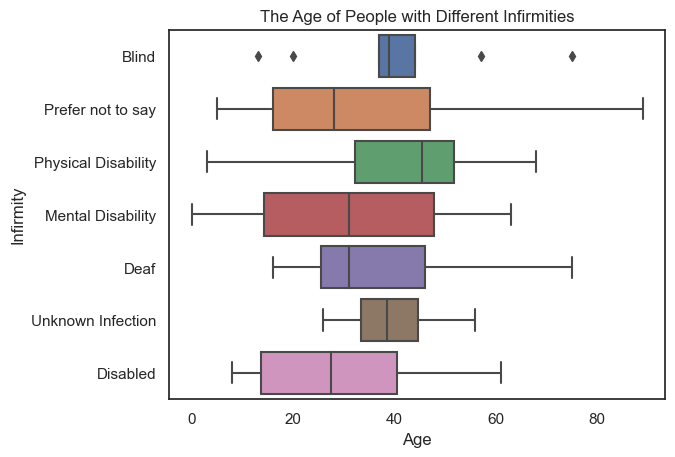

In [76]:
# Plotting a Graph Showing the Age disrtribution of Infirmities
sns.boxplot(x = 'Age',y = 'Infirmity', data=df,);
plt.title('The Age of People with Different Infirmities');

###### Calculating the Occupancy Level

In [77]:
# Examine the occupancy level per house; 


# Group the data by Surname and count the number of people in each house
household_size = df.groupby('Surname')['Street'].count()

# Calculate the average household size
avg_household_size = household_size.mean()

# Display the average household size
print(f"The average household size is {avg_household_size:.2f} people per house.")

The average household size is 12.71 people per house.


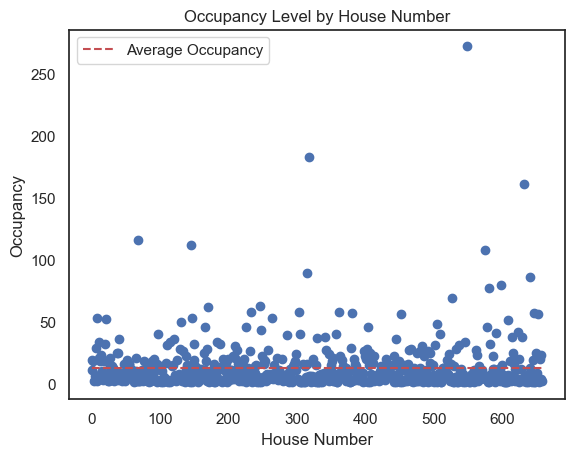

In [78]:
# calculate the number of people in each house
occupancy = df.groupby('Surname').size()

# calculate the average number of people per house in the neighborhood
avg_occupancy = occupancy.sum() / len(occupancy)

# create a new DataFrame with occupancy information and whether each house is under or over-used
results = pd.DataFrame({'Occupancy': occupancy, 'Average Occupancy': avg_occupancy})
results['Status'] = ['Under-used' if x < avg_occupancy else 'Over-used' for x in occupancy]

# plot a scatterplot of occupancy level by house number
plt.scatter(range(len(occupancy)), occupancy)
plt.plot([0, len(occupancy)], [avg_occupancy, avg_occupancy], 'r--', label='Average Occupancy')
plt.xlabel('House Number')
plt.ylabel('Occupancy')
plt.title('Occupancy Level by House Number')
plt.legend();

In [79]:
# Removing Age Group column 
df = df.drop(columns=['Age Group'])

###### Calculating Birth Rate 

In [83]:
# Calculating birth rate
new_birth = df['Age']==0
new_birth.sum()

89

In [84]:
# number of potential women of childbearing age.
Women_of_child_bearing_age = 0
 

for women in df['Gender']:
    if women == 'Female':
        Women_of_child_bearing_age += 1

print(Women_of_child_bearing_age)

4374


In [85]:
# Calculating birth rate
Birth_rate = round(89/4374*1000)
print('Birth_rate:', str(Birth_rate) + ' Per 1000')

Birth_rate: 20 Per 1000


In [95]:
# Saving the cleaned copy of census 11
# df.to_csv('C:/Users/ezeik/Desktop/MSc AI & DS Hull/Fund of DS 80% Assignment/census11.CleanedCopy.csv')